# Inspection

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load config
import sys
import os
from pathlib import Path
import datajoint as dj
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

from model_in_the_loop.utils.hydra_utils import load_config,set_env_vars
cfg = load_config()
set_env_vars(cfg)  # set env variables for repo and data paths



/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


home directory: /gpfs01/euler/User/ssuhai


In [3]:
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils as dj_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.rf_mei_test_tables as dj_tab
import thesis.code.validate_online_analysis.utils as val_ut
# import plotter
import thesis.code.plot.plot as plotter
plotter.set_default_params(kind='paper')

FIGURE_PATH = os.path.join(cfg.paths.repo_directory, 'thesis', 'figures', 'analysis_closed_loop_experiments', 'rf_mei_test')
os.makedirs(FIGURE_PATH, exist_ok=True)

print("importing dj_utils")
from thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils import *
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.mei_utils as mei_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.stats_utils as su


importing dj_utils


In [4]:
load_dj_config(
    config_file = os.path.join(cfg.paths.home_directory,cfg.paths.dj_config_directory, f'dj_{cfg.DJ.username}_conf.json'),
    schema_name =  f"ageuler_ssuhai_closed_loop_rf_mei"
)

[2025-11-04 17:48:50,883][INFO]: DataJoint is configured from /gpfs01/euler/User/ssuhai/datajoint/dj_ssuhai_conf.json
[2025-11-04 17:48:50,968][INFO]: DataJoint 0.14.6 connected to ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop_rf_mei


In [5]:
prepclassifier_and_activate(
    output_folder = os.path.join(cfg.paths.home_directory,cfg.paths.rgc_output_directory),
)

In [10]:
optsim_field_kes = (Field() & (StimulusPresentationInfo() & "stim_name='optstim'")).proj().fetch(as_dict=True)
optsim_field_kes    

[{'experimenter': 'Deja',
  'date': datetime.date(2025, 10, 8),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL4',
  'region': 'LR',
  'cond1': 'control'},
 {'experimenter': 'Deja',
  'date': datetime.date(2025, 10, 8),
  'exp_num': 2,
  'raw_id': 1,
  'field': 'GCL2',
  'region': 'RR',
  'cond1': 'control'}]

In [11]:
model_true_df1,roi_ids1 = mei_ut.wrapper_fetch_complete_field_df(
            optsim_field_kes[0],
        Offline2OnlineRoiId,
        CascadeTraces,
        CascadeSpikes,
        StimulusPresentationInfo,
        OnlineInferredRFPosition,
        Presentation,)

rois: [23 25 27 34 58 79 95]
Grouping by columns: ['stim_type', 'roi_id', 'online_roi_id'], reducing df cols over {'snippet', 'true_online_roi_id', 'x_rf', 'snippet_t0', 'snippet_times', 'cond2', 'snippet_triggertimes', 'positions', 'snippet_dt', 'y_rf'}
Number of unique groups: 294
Averaged df over columns: ['snippet', 'snippet_triggertimes', 'positions', 'x_rf', 'y_rf', 'true_online_roi_id', 'snippet_dt', 'snippet_t0'], resulting df has 294 rows. Differece in rows: 588
/gpfs01/euler/data/Data/Suhai/thesis/other_data/FloDeja/20251008/1/mei_GCL4
Index(['stim_type', 'roi_id_data', 'online_roi_id', 'snippet',
       'snippet_triggertimes', 'positions', 'x_rf', 'y_rf',
       'true_online_roi_id', 'snippet_dt', 'snippet_t0', 'stim_type_new',
       'readout_idx', 'roi_id_model', 'mei_id', 'seed', 'mei',
       'temporal_kernels', 'spatial_kernels', 'stability',
       'responses_all_readout_idx', 'mean_responses_all_readout_idx'],
      dtype='object')
true_online_roi_id: 23.0, readout_id

In [12]:
celltype_df1 = mei_ut.fetch_celltype_df(CelltypeAssignment,
    Offline2OnlineRoiId,
    Presentation,
    field_key=optsim_field_kes[0],
)
print(celltype_df1)

# model_true_df1 = mei_ut.add_celltype_column(
#     model_true_df1,
#     celltype_df1,
# )

experimenter='Deja' AND date='2025-10-08' AND exp_num='1' AND raw_id='1' AND field='GCL4' AND region='LR' AND cond1='control'AND roi_id IN (7,12,22,23,25,28,31,33,35,36,40,47,59,60,65,67,77,78,83,84,85,23,25,27,34,58,79,95,2,4,7,8,9,14,16,20,29,40,57,73,76,80,87,92,2,40,45,45,51,52,62,77,77,82,82)
   celltype  roi_id_data
0        22           23
1        32           25
2        22           27
3        22           34
4        11           58
5        31           79
6        22           95


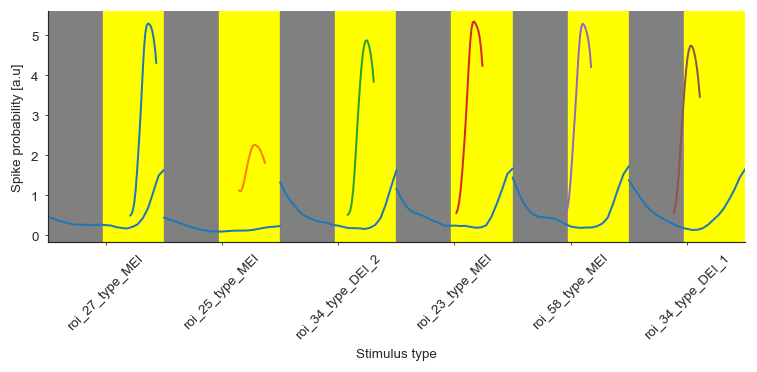

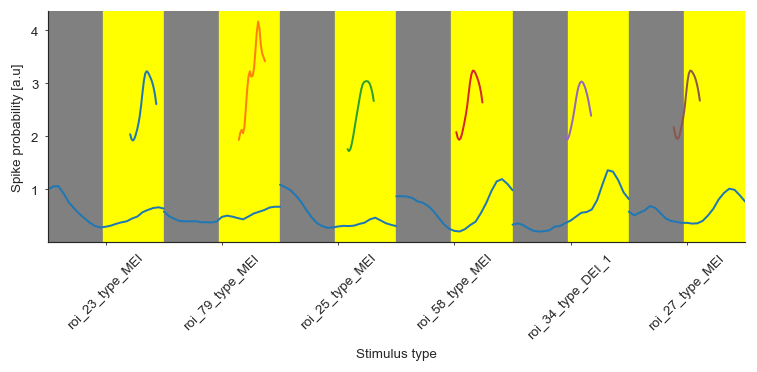

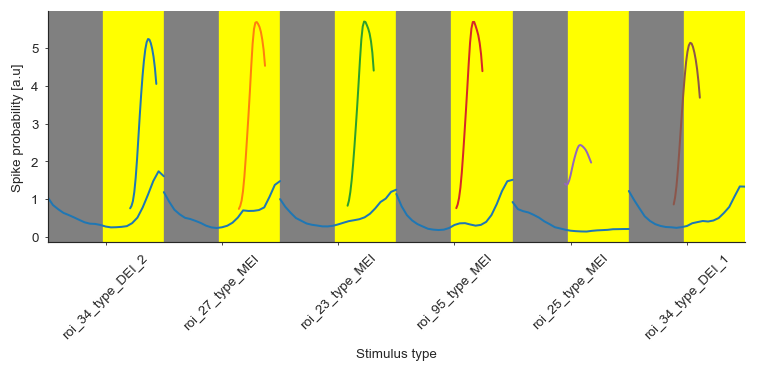

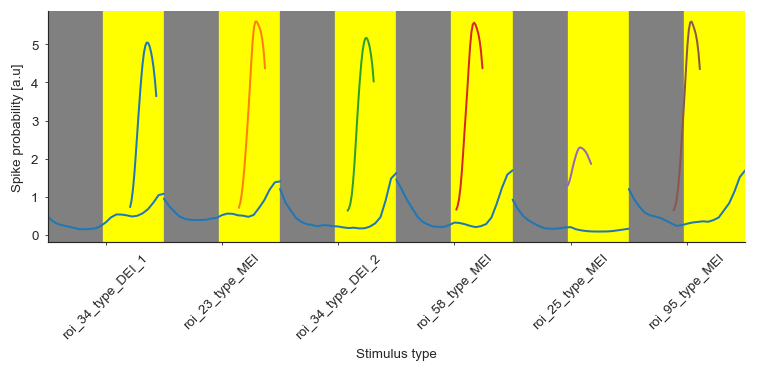

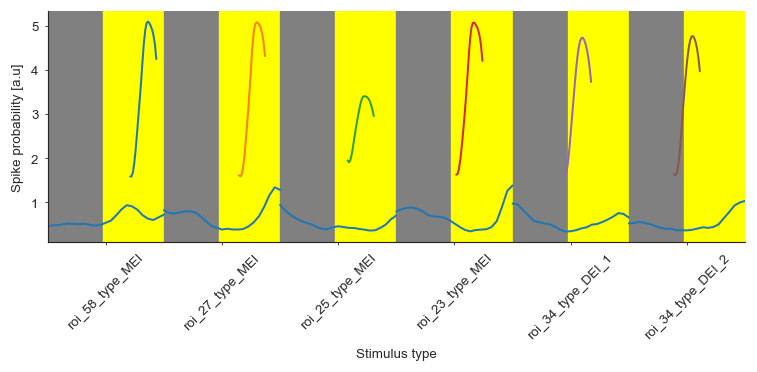

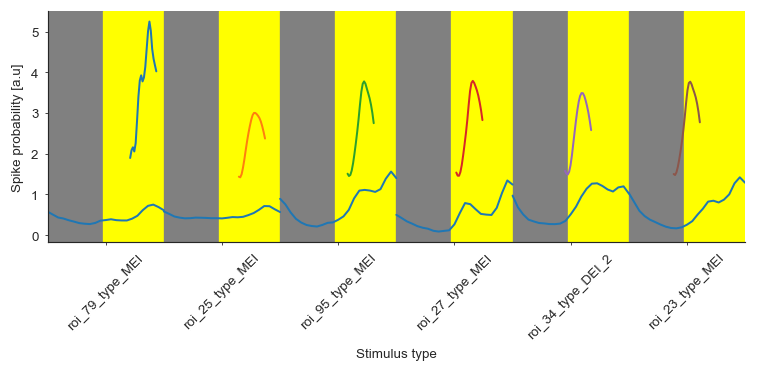

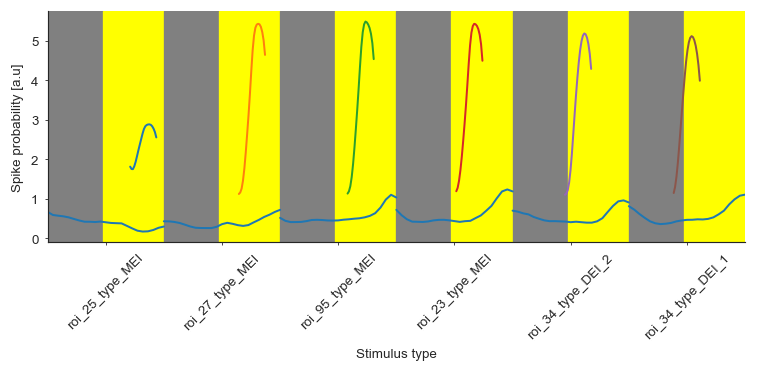

In [13]:
for i in range(len(roi_ids1)):
    mei_ut.plot_ordered_spike_snippets(
        df=model_true_df1[model_true_df1["true_online_roi_id"] == roi_ids1[i]],
        sort_by="snippet_triggertimes",
    )

['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_58_type_MEI']
[23, 25, 27, 34, 34, 58]
[22, 32, 22, 22, 22, 11]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]
['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_58_type_MEI', 'roi_79_type_MEI']
[23, 25, 27, 34, 58, 79]
[22, 32, 22, 22, 11, 31]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]
['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_95_type_MEI']
[23, 25, 27, 34, 34, 95]
[22, 32, 22, 22, 22, 22]
[0.         0.03333333 0.06666667 0.1        

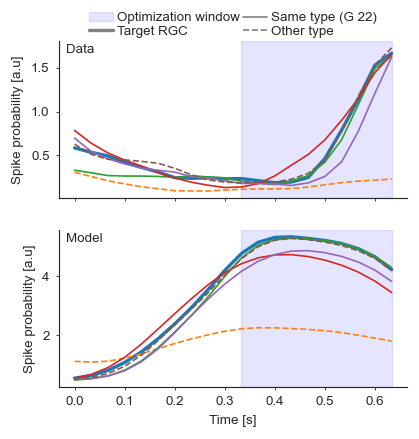

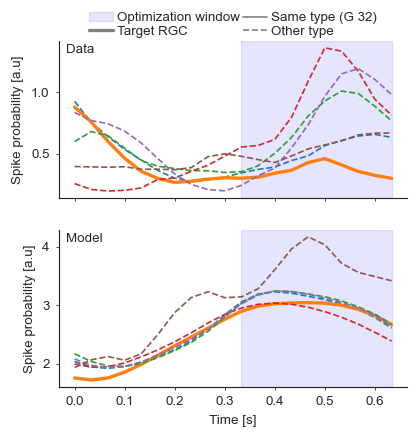

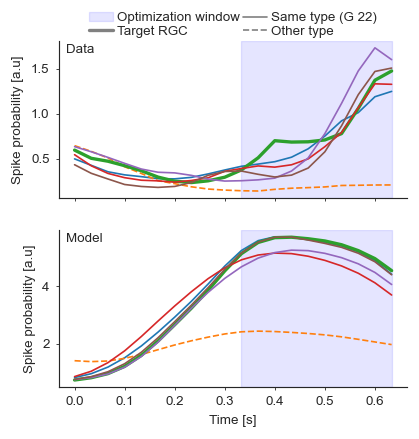

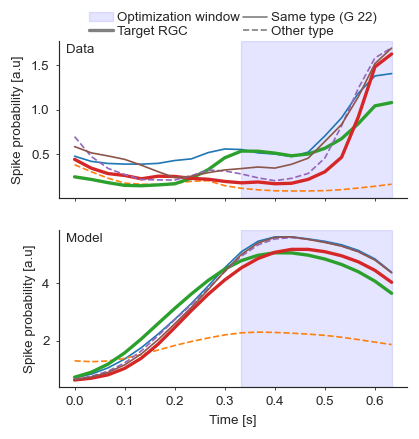

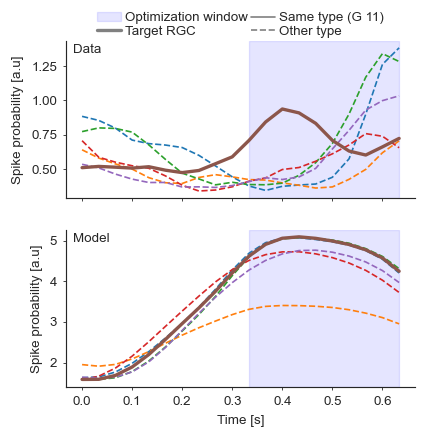

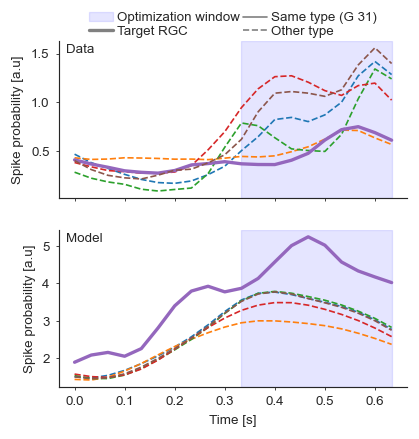

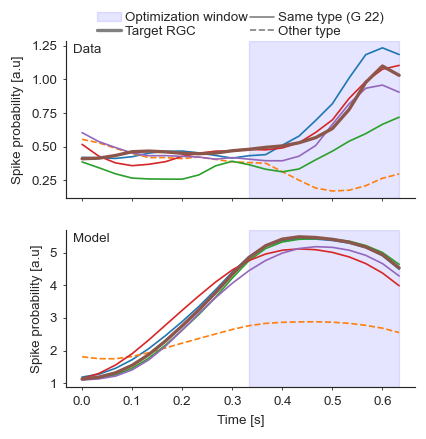

In [14]:
for i,roi in enumerate(roi_ids1):
    df_bool_mask = model_true_df1["true_online_roi_id"] == roi

    mei_ut.fetch_and_plot_snippets_subplots(model_true_df1[model_true_df1["true_online_roi_id"] == roi],
                                            celltypes_df =celltype_df1,
                                            proxy_legend=True)

Observations for field GCL 4 exp 1:
- the model predicted activity is often much higher than the actual activity
- the time scaele of the predicted response seems to be off. Systematically delayed actual traces
- the optimizes stimuli are predicted to have very similar responses This is because  4 out of the 7 cells are type 22

Inspecting the videos: 
- All G22 look quite similar
- The G11 looks soehow too similar to G22s MEIs, missing som eh the high frequencies (also way less activity than predicted by the model)
- G 32 seeems to have some spatial artifact -> leading to low activity in acutla neuron 
- G 31 does have characteristic high frequency UV but spatilally again artefact -> low activity

So overall problems:
-  Actual neurons that have different temporal dynamics in respone to optimized stimulithen than predicted -> implies that the model did not learn temporal dynamics of cell well 
- spatial artifacts
- two very similar MEIs for actually different cell types


Comparing the MEI videos to laras MEIs 

Overal good things: 
- seems to capure temporal characteristics according to cell type for G31
- G22 is an on cell so it does seem to give a strong UV on response at end and also manages to 
- for some cells the relationshipe between prediceted activity in optimization window and actual is significant. 


--> Overall conclusion: 
a) There seems to be something funky going on during the optimization process
b) this can effect some cells more than others 
c) You cannot conclude that the model did not learn the SR function at all since for some cells it still predicts which stimuli lead to higher repsonses


['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_95_type_MEI']
[23, 25, 27, 34, 34, 95]
[22, 32, 22, 22, 22, 22]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]
['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_95_type_MEI']
[23, 25, 27, 34, 34, 95]
[22, 32, 22, 22, 22, 22]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]


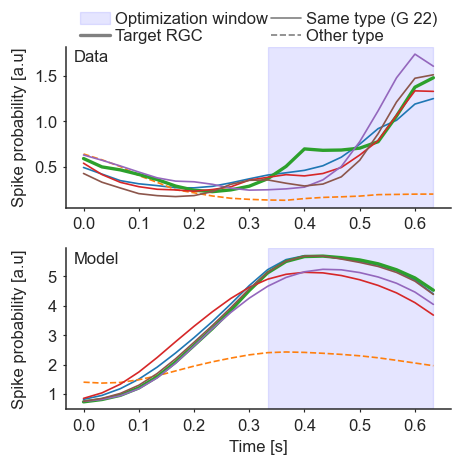

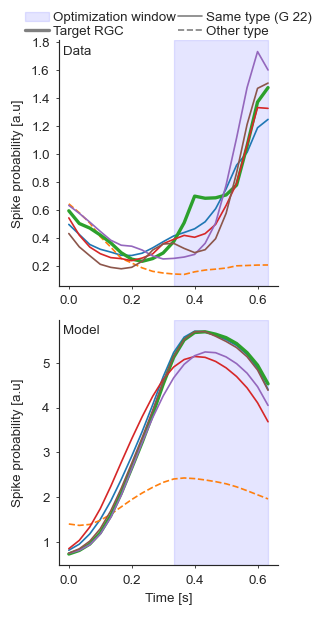

In [21]:
plotter.set_default_params(kind='talk')
fig,ax = plt.subplots(2,1,figsize=plotter.figsize_from_frac(1/2,1/2))
mei_ut.fetch_and_plot_snippets_subplots(model_true_df1[model_true_df1["true_online_roi_id"] == 27],
                                        celltypes_df =celltype_df1,
                                        axes=ax,
                                        proxy_legend=True)

plotter.tight_layout()
fig_name= os.path.join(FIGURE_PATH,f"prediceted_actual_sippets_subplots_roi27_GCL4_presentation.jpg")
plt.savefig(fig_name)
fig.align_ylabels(ax)  # This will align all y-labels
    

plotter.set_default_params(kind='paper')
fig,ax = plt.subplots(2,1,figsize=plotter.figsize_from_frac(1/3,2/3))
mei_ut.fetch_and_plot_snippets_subplots(model_true_df1[model_true_df1["true_online_roi_id"] == 27],
                                        celltypes_df =celltype_df1,
                                        axes=ax,
                                        proxy_legend=True)

plotter.tight_layout()
fig_name= os.path.join(FIGURE_PATH,f"prediceted_actual_sippets_subplots_roi27_GCL4_paper.svg")
fig.align_ylabels(ax)  # This will align all y-labels

plt.savefig(fig_name,format='svg',bbox_inches='tight')

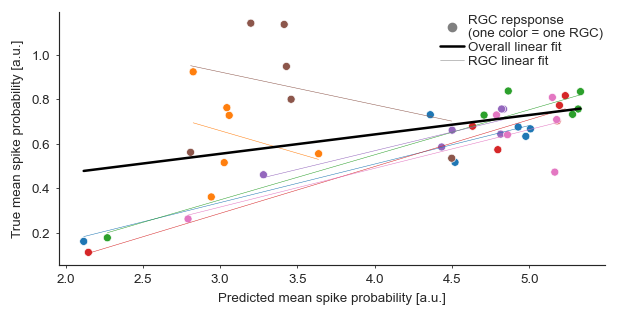

In [16]:
plotter.set_default_params(kind='paper')
fig,ax = plt.subplots(1,1,figsize=plotter.figsize_from_frac(2/3,1/3))
mei_ut.plot_predicted_vs_true_scalar_value(
    df = model_true_df1,
    predicted_col="predicted_response_last_10_frames_mean",
    true_col="snippet_last_10_frames_mean",
    ax=ax,
)
plotter.tight_layout()
fig_name= os.path.join(FIGURE_PATH,f"predicted_vs_true_response_last10frames_mean_GCL4_paper.svg")
plt.savefig(fig_name,format='svg',bbox_inches='tight')

In [17]:
boot_results = su.bootstrap(
    full_df = model_true_df1,
    x_col = "predicted_response_last_10_frames_mean",
    y_col = "snippet_last_10_frames_mean",
    identity_col = "true_online_roi_id",)
boot_results["significant"] = boot_results["low"] * boot_results["high"] > 0
boot_results

analyzing for type 23.0
analyzing for type 25.0
analyzing for type 27.0
analyzing for type 34.0
analyzing for type 58.0
analyzing for type 79.0
analyzing for type 95.0


,true_online_roi_id,low,high,poly_power,significant
0,23.0,-0.878503,1.290399,0,False
1,23.0,-0.128341,0.309058,1,False
2,25.0,-10.359111,5.087122,0,False
3,25.0,-1.493847,3.637509,1,False
4,27.0,-0.373658,1.591019,0,False
5,27.0,-0.157032,0.241981,1,False
6,34.0,-1.909663,0.130897,0,False
7,34.0,0.117838,0.517650,1,True
8,58.0,-1.271674,0.144336,0,False
9,58.0,0.108206,0.420897,1,True


# figures paper

In [6]:
optsim_field_kes = (Field() & (StimulusPresentationInfo() & "stim_name='optstim'")).proj().fetch(as_dict=True)
optsim_field_kes    

[{'experimenter': 'Deja',
  'date': datetime.date(2025, 10, 8),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL4',
  'region': 'LR',
  'cond1': 'control'},
 {'experimenter': 'Deja',
  'date': datetime.date(2025, 10, 8),
  'exp_num': 2,
  'raw_id': 1,
  'field': 'GCL2',
  'region': 'RR',
  'cond1': 'control'}]

In [7]:
# get data from field again with spatial and temporal kernels
model_true_df1,roi_ids1 = mei_ut.wrapper_fetch_complete_field_df(
            optsim_field_kes[0],
        Offline2OnlineRoiId,
        CascadeTraces,
        CascadeSpikes,
        StimulusPresentationInfo,
        OnlineInferredRFPosition,
        Presentation,
        cols_to_drop = ["mei"], # keep spatial and temporal kernels
        )



celltype_df1 = mei_ut.fetch_celltype_df(CelltypeAssignment,
    Offline2OnlineRoiId,
    Presentation,
    field_key=optsim_field_kes[0],
)
print(celltype_df1)

rois: [23 25 27 34 58 79 95]
Grouping by columns: ['stim_type', 'roi_id', 'online_roi_id'], reducing df cols over {'snippet_dt', 'snippet_triggertimes', 'snippet', 'snippet_t0', 'true_online_roi_id', 'positions', 'snippet_times', 'cond2', 'y_rf', 'x_rf'}
Number of unique groups: 294
Averaged df over columns: ['snippet', 'snippet_triggertimes', 'positions', 'x_rf', 'y_rf', 'true_online_roi_id', 'snippet_dt', 'snippet_t0'], resulting df has 294 rows. Differece in rows: 588
/gpfs01/euler/data/Data/Suhai/thesis/other_data/FloDeja/20251008/1/mei_GCL4
true_online_roi_id: 23.0, readout_idx: 5
true_online_roi_id: 25.0, readout_idx: 6
true_online_roi_id: 27.0, readout_idx: 7
true_online_roi_id: 34.0, readout_idx: 8
true_online_roi_id: 58.0, readout_idx: 12
true_online_roi_id: 79.0, readout_idx: 15
true_online_roi_id: 95.0, readout_idx: 21
true_online_roi_id: 23.0, readout_idx: 5
true_online_roi_id: 25.0, readout_idx: 6
true_online_roi_id: 27.0, readout_idx: 7
true_online_roi_id: 34.0, readout_i

## MEIs themselves

In [8]:
sel_rois = [27,58,79] #[27,58,25]

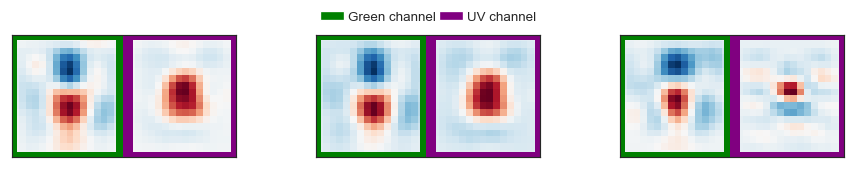

In [61]:
# get spatial kerns for rois
def fetch_kernels(roi_ids: List[int],df:pd.DataFrame,return_by_channels: bool =True,type_="spatial") -> np.ndarray:
    assert type_ in ["spatial","temporal"], "type_ must be either 'spatial' or 'temporal'"

    all_kerns = []
    for roi in roi_ids:
        
    
        kerns = df[(df["true_online_roi_id"] == roi) & \
            (df["stim_type"].apply(lambda str_: int(str_.split("_")[1])) == roi)]
        all_kerns.append(kerns[f"{type_}_kernels"].item())

    all_kerns = np.asarray(all_kerns)
    assert all_kerns.shape[0] == len(roi_ids), f"Mismatch in number of ROI IDs and kernels fetched : {len(roi_ids)} vs {kerns.shape[0]}"
    assert all_kerns.shape[1] == 2, "Each kernel entry must be a list of two arrays (for two channels)"

    if return_by_channels:
        
        # now first dim is channel, second is roi id 
        all_kerns = all_kerns.transpose((1,0,  *list(range(2,all_kerns.ndim))))
    return all_kerns


# fetch spatial kernels for roi 27,58,25
spatial_kernels = fetch_kernels(sel_rois,model_true_df1,return_by_channels=True)

fig,ax = plt.subplots(1,3,figsize=plotter.figsize_from_frac(1,1/6))


ax = pu.plot_2d_array_comparison(
    array1=spatial_kernels[0],
    array2=spatial_kernels[1],
    axes=ax,
    array_colors = ("green","purple"),
    norm_type="joint",
    gap_width=1
)

# add legend 
from matplotlib.patches import Patch

legend_elements = [
Patch(facecolor="green", label='Green channel'),
Patch(facecolor="purple", label='UV channel'),
]

ax[1].legend(handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.07),
        ncol=len(legend_elements),
        frameon=False
        )

plotter.tight_layout()
fig_name = "spaital_kernels_optstim_roi27_58_79"
plt.savefig(os.path.join(FIGURE_PATH,f"{fig_name}.svg"),format='svg',bbox_inches='tight')

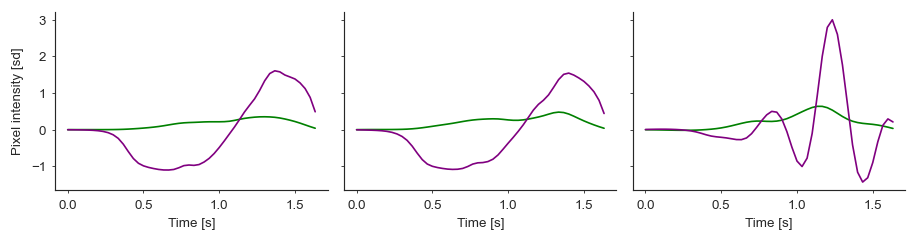

In [60]:
# temporal kernels
temporal_kernels = fetch_kernels(sel_rois,model_true_df1,return_by_channels=False,type_="temporal")

fig,axes = plt.subplots(1,3,figsize=plotter.figsize_from_frac(1,3/12),sharey=True)


# plot
pu.plot_2time_series( # reuse this for green vs uv temporal kernels 
    temporal_kernels,
    axes = axes,
)
axes[0].set_ylabel("Pixel intensity [sd]")
plotter.tight_layout()
fig_name = "temporal_kernels_optstim_roi27_58_79"
plt.savefig(os.path.join(FIGURE_PATH,f"{fig_name}.svg"),format='svg',bbox_inches='tight')


## predicted and actual responses

['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_95_type_MEI']
[23, 25, 27, 34, 34, 95]
[22, 32, 22, 22, 22, 22]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]
['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_1', 'roi_34_type_DEI_2', 'roi_58_type_MEI']
[23, 25, 27, 34, 34, 58]
[22, 32, 22, 22, 22, 11]
[0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333]
['roi_23_type_MEI', 'roi_25_type_MEI', 'roi_27_type_MEI', 'roi_34_type_DEI_2', 'roi_79_type_MEI', 'roi_95_type_MEI']
[23, 25, 27, 34, 79, 95]
[22, 32, 22, 22, 31, 22]
[0.         0.03333333 0.06666667 0.1        

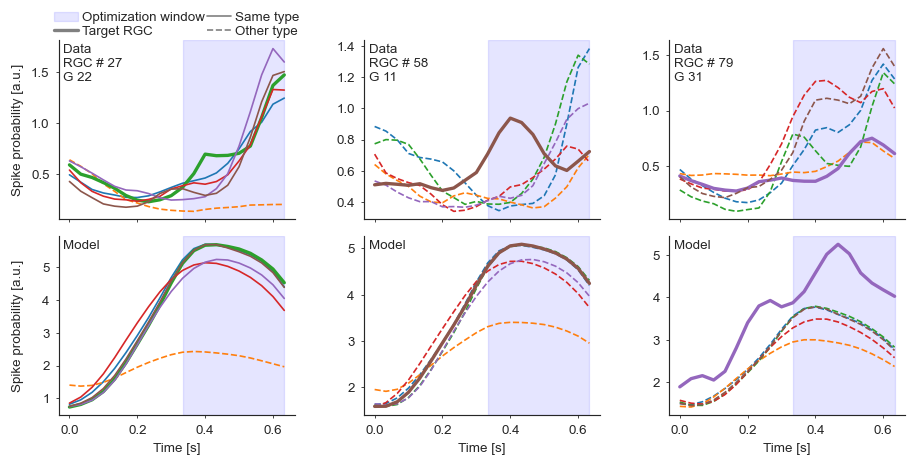

In [59]:
fig,axes = plt.subplots(2,3,figsize=plotter.figsize_from_frac(1,6/12),sharex=True)
for i,roi in enumerate(sel_rois):
    df_bool_mask = model_true_df1["true_online_roi_id"] == roi

    ax = axes[:,i]
    _,_ = mei_ut.fetch_and_plot_snippets_subplots(model_true_df1[model_true_df1["true_online_roi_id"] == roi],
                                            celltypes_df =celltype_df1,
                                            axes=ax,
                                            proxy_legend=False)
    
    # remove all legends    
    ax[0].legend_.remove()

    # remove al y labels except first col
    for axi in ax:
        axi.set_ylabel("")

# add one y label each row in first column 
text = "Spike probability [a.u.]"
for axi in axes[:,0]:
    axi.set_ylabel(text)

# make ylabels align horizontally
fig.align_ylabels(axes[:,0])

#
legend_params = {
    "bbox_to_anchor": (0.5, 1.0),
    "loc": "lower center",
    "ncol": 2,
    "frameon": False,
}

# get cell type info
selected_cell_types = [celltype_df1[celltype_df1["roi_id_data"] == roi]["celltype"].item() for roi in sel_rois]

# prxy patch for optimization window
optimization_proxy = plt.Rectangle((0, 0), 1, 1, color='blue', alpha=0.1)

# add proxy legend thick same cell - same type - thin other type
same_cell_proxy = plt.Line2D([0], [0], color='grey', linewidth=2.0, linestyle='-')
same_type_proxy = plt.Line2D([0], [0], color='grey', linewidth=1.0, linestyle='-')
other_type_proxy = plt.Line2D([0], [0], color='grey', linewidth=1.0, linestyle='--')

axes[0,0].legend([optimization_proxy,same_cell_proxy, same_type_proxy, other_type_proxy],
            ["Optimization window","Target RGC", f"Same type", "Other type"],
            **legend_params)

plotter.tight_layout()
fig_name = "thee_model_vs_true_optstim_snippets"

fig.savefig(os.path.join(FIGURE_PATH,f"{fig_name}.svg"),format='svg',bbox_inches='tight')


## scalar summary per stimulus

### regression plot

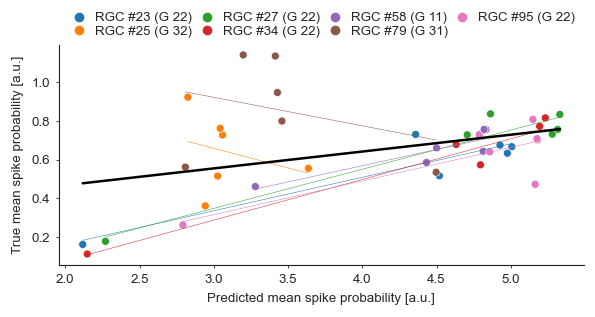

In [62]:
fig,ax = plt.subplots(1,1,figsize=plotter.figsize_from_frac(2/3,1/3))
import matplotlib.lines as mlines

# turn true_online_roi_id column into int for plotting wo poin
model_true_df1["true_online_roi_id"] = model_true_df1["true_online_roi_id"].astype(int)

mei_ut.plot_predicted_vs_true_scalar_value(
    df = model_true_df1,
    predicted_col="predicted_response_last_10_frames_mean",
    true_col="snippet_last_10_frames_mean",
    ax=ax,
)

color_palette = sns.color_palette("tab10", n_colors=model_true_df1["true_online_roi_id"].nunique())
color_map = {roi_id: color_palette[i] for i, roi_id in enumerate(sorted(model_true_df1["true_online_roi_id"].unique()))}


# remove legend
ax.legend_.remove()

# add own -> roi ID and cell type
legend_handles = []
for roi,color in color_map.items():
    celltype = celltype_df1[celltype_df1["roi_id_data"] == roi]["celltype"].item()
    legend_handles.append(
        mlines.Line2D([],[],marker = "o",color=color, linestyle = "None", label=f"RGC #{roi} (G {celltype})")
    )

# add legend
ax.legend(handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=False
        )

plotter.tight_layout()
fig_name= os.path.join(FIGURE_PATH,f"predicted_vs_true_response_last10frames_mean_GCL4_paper.svg")
plt.savefig(fig_name,format='svg',bbox_inches='tight')

### boot straped CI plot

In [42]:
boot_results = su.bootstrap(
    full_df = model_true_df1,
    x_col = "predicted_response_last_10_frames_mean",
    y_col = "snippet_last_10_frames_mean",
    identity_col = "true_online_roi_id",)
boot_results["significant"] = boot_results["low"] * boot_results["high"] > 0
boot_results

analyzing for type 23
analyzing for type 25
analyzing for type 27
analyzing for type 34
analyzing for type 58
analyzing for type 79
analyzing for type 95


,true_online_roi_id,low,high,poly_power,significant
0,23,-0.919839,1.290409,0,False
1,23,-0.128357,0.318422,1,False
2,25,-9.995959,5.203507,0,False
3,25,-1.573361,3.517292,1,False
4,27,-0.347846,1.548612,0,False
5,27,-0.147952,0.234976,1,False
6,34,-1.969900,0.080519,0,False
7,34,0.128126,0.528688,1,True
8,58,-1.332949,0.088314,0,False
9,58,0.116439,0.433000,1,True


In [52]:
# format df for plotting 
df_plot = pu.make_plot_df(boot_results, only_order_n=1)

# add celltype 
df_plot = df_plot.merge(
    celltype_df1,
    left_on="true_online_roi_id",
    right_on="roi_id_data",
)
df_plot["cell_label"] = df_plot.apply(lambda row: f"# {row['true_online_roi_id']} (G {row['celltype']})", axis=1)
df_plot

,true_online_roi_id,low,high,poly_power,significant,mid,err_low,err_high,celltype,roi_id_data,cell_label
0,23,-0.128357,0.318422,1,False,0.095033,0.223389,0.223389,22,23,# 23 (G 22)
1,25,-1.573361,3.517292,1,False,0.971965,2.545326,2.545326,32,25,# 25 (G 32)
2,27,-0.147952,0.234976,1,False,0.043512,0.191464,0.191464,22,27,# 27 (G 22)
3,34,0.128126,0.528688,1,True,0.328407,0.200281,0.200281,22,34,# 34 (G 22)
4,58,0.116439,0.433000,1,True,0.274720,0.158281,0.158281,11,58,# 58 (G 11)
5,79,-1.192016,0.859355,1,False,-0.166330,1.025686,1.025686,31,79,# 79 (G 31)
6,95,-0.444679,0.278866,1,False,-0.082906,0.361773,0.361773,22,95,# 95 (G 22)


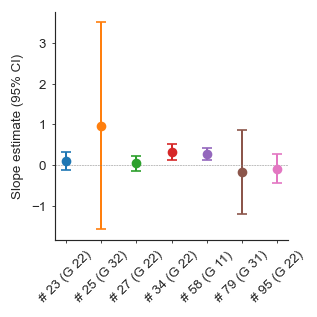

In [54]:
fig,ax = plt.subplots(1,1,figsize=plotter.figsize_from_frac(1/3,1/3))
ax = pu.plot_points_and_ci(df_plot,column="cell_label",ax =ax,xtick_angle=45)
ax.set_ylabel("Slope estimate (95% CI)")
plotter.tight_layout()
fig_name = "slope_CI_celltype_optstim"
plt.savefig(os.path.join(FIGURE_PATH,f"{fig_name}.svg"),format='svg',bbox_inches='tight')